### Libraries

In [1]:
import networkx as nx
from shapely.geometry import Point,LineString,Polygon

import simpy
import xarray as xr

from opentnsim import lock_new as lock_module
from opentnsim.core import vessel_properties as vessel_module
from opentnsim import vessel_traffic_service as vessel_traffic_service_module
import datetime
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import pickle
import matplotlib.dates as mdates
import folium
from shapely.ops import nearest_points, linemerge, split, snap, transform
import pyproj
import re
path = os.getcwd()
import opentnsim.core as core
from opentnsim.core import VesselProperties, ExtraMetadata
from opentnsim.graph import HasMultiDiGraph
from opentnsim.output import HasOutput

In [2]:

class IsVessel(core.Identifiable, core.Movable, VesselProperties, ExtraMetadata, HasMultiDiGraph, HasOutput):

    def __init__(self, *args, **kwargs):
        self.overruled_speed = pd.DataFrame(
            data=[], columns=["Speed"], index=pd.MultiIndex.from_arrays([[], [], []], names=("node_start", "node_stop", "k"))
        )
        super().__init__(*args, **kwargs)

    def distance_to_desired_speed(self, v_target, h0, v0=None, P_used=1):
        dt = 1
        times = np.arange(0, 86400, dt)
        x1 = 0.0
        if v0 is None:
            v0 = self.current_speed
        else:
            v0 = v0
        x = []
        a = []
        v = []
        t = []
        amax = 0.3
        Power_vessel = P_used * self.P_installed
        breaking = False
        if v0 > v_target:
            breaking = True
            amax = -amax
            Power_vessel = -Power_vessel
        for t1 in times:
            F = -self.calculate_total_resistance(v0, h0) * 1000 + Power_vessel / v0
            mass_vessel = 0.85 * 1000 * self.T * self.B * self.L
            a1 = np.min([F / mass_vessel, amax])
            if breaking:
                a1 = np.max([F / mass_vessel, amax])
            v1 = a1 * dt + v0
            x1 += 0.5 * (v1**2 - v0**2) / a1
            v0 = v1
            if (not breaking and v1 >= v_target) or (breaking and v1 <= v_target):
                v1 = v_target
            a.append(a1)
            x.append(x1)
            v.append(v1)
            t.append(t1)
            if (not breaking and v1 >= v_target) or (breaking and v1 <= v_target):
                break

        x_total = x[-1]
        t_tot = t[-1]
        v_end = v[-1]
        v_avg = x[-1] / t[-1]
        output = {
            "sailed_distance": x_total,
            "sailing_time": t_tot,
            "end_velocity": v_end,
            "average_velocity": v_avg,
            "distance": x,
            "velocity": v,
            "acceleration": a,
            "time": t,
        }

        return output


### Simulation

In [3]:
env = simpy.Environment()
t_start = datetime.datetime(2025, 1, 1, 0, 0, 0)
t_stop = datetime.datetime(2026, 1, 1, 0, 0, 0)

env = simpy.Environment(initial_time=t_start.timestamp())
env.epoch = t_start
env.simulation_start = t_start
env.simulation_stop = t_stop

### Network

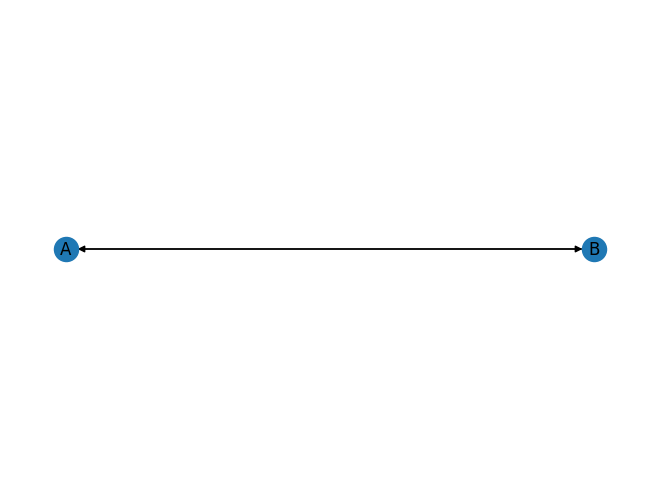

In [4]:
wgs84eqd = pyproj.CRS('4087')
wgs84rad = pyproj.CRS('4326')
wgs84eqd_to_wgs84rad = pyproj.transformer.Transformer.from_crs(wgs84eqd,wgs84rad,always_xy=True).transform
wgs84rad_to_wgs84eqd = pyproj.transformer.Transformer.from_crs(wgs84rad,wgs84eqd,always_xy=True).transform

graph = nx.MultiDiGraph()
graph.add_node('A',geometry=transform(wgs84eqd_to_wgs84rad,Point(-5000,0)))
graph.add_node('B',geometry=transform(wgs84eqd_to_wgs84rad,Point(5000,0)))
graph.add_edge('A','B',geometry=transform(wgs84eqd_to_wgs84rad,LineString([Point(-5000,0),Point(5000,0)])),length=10000)
graph.add_edge('B','A',geometry=transform(wgs84eqd_to_wgs84rad,LineString([Point(5000,0),Point(-5000,0)])),length=10000)
pos = {edge:(point.x,point.y) for edge,point in nx.get_node_attributes(graph, 'geometry').items()}
nx.draw(graph,pos,with_labels=True)
env.FG = graph

### Vessel traffic services

In [5]:
env.vessel_traffic_service = vessel_traffic_service_module.VesselTrafficService(FG=graph)

### Lock object

In [ ]:
NewLock = type('NewLock',(lock_module.IsLockComplex,ExtraMetadata,),{})
lock = NewLock(env=env,
                                 name='Lock',
                                 start_node='A',
                                 node_open='A',
                                 end_node='B',
                                 node_A = 'A',
                                 node_B = 'B',
                                 distance_lock_doors_A_to_waiting_area_A = 4800,
                                 distance_lock_doors_B_to_waiting_area_B = 4800,
                                 distance_from_start_node_to_lock_doors_A = 4800,
                                 distance_from_end_node_to_lock_doors_B = 4800,
                                 lock_length = 400,
                                 lock_width = 50,
                                 lock_depth = 15,
                                 levelling_time = 300,
                                 sailing_distance_to_crossing_point = 1800,
                                 doors_opening_time= 300,
                                 doors_closing_time= 300,
                                 speed_reduction_factor_lock_chamber=0.5,
                                 sailing_in_time_gap_through_doors = 300,
                                 sailing_in_speed_sea = 1.5,
                                 sailing_in_speed_canal = 1.5,
                                 sailing_out_time_gap_through_doors = 120,
                                 sailing_time_before_opening_lock_doors = 600,
                                 sailing_time_before_closing_lock_doors = 120,
                                 detector_nodes = ['A','B'],
                                 predictive=False,
                                 )

ValueError: Routable route must be on the graph

### Vessels

In [ ]:
Vessel = type('Vessel',(lock_module.PassesLockComplex,vessel_module.IsVessel,),{})

In [ ]:
vessel_1 = Vessel(**{"env": env,
                     "name": 'Vessel 1',
                     "origin": 'A',
                     "destination": 'B',
                     "type": 'tanker',
                     "bound": 'outbound',
                     "L": 100,
                     "B": 20,
                     "T": 10,
                     "v": 4,
                     "P_installed": 50000*1000,
                     "C_year": 2010,
                     "L_w":3,
                     "arrival_time": pd.Timestamp('2025-01-01 00:00:00')})
vessel_1.process = env.process(vessel_1.move())

vessel_2 = Vessel(**{"env": env,
                     "name": 'Vessel 2',
                     "origin": 'B',
                     "destination": 'A',
                     "type": 'tanker',
                     "bound": 'outbound',
                     "L": 100,
                     "B": 20,
                     "T": 10,
                     "v": 4,
                     "P_installed": 50000*1000,
                     "C_year": 2010,
                     "L_w":3,
                     "C_year": 2010,
                     "arrival_time": pd.Timestamp('2025-01-01 00:05:00')})
vessel_2.process = env.process(vessel_2.move())

vessels = []
vessels.append(vessel_1)
vessels.append(vessel_2)

### Run model

In [ ]:
env.run()

In [ ]:
lock_df = pd.DataFrame(lock.logbook)
vessel_df1 = pd.DataFrame(vessel_1.logbook)
vessel_df2 = pd.DataFrame(vessel_2.logbook)

In [ ]:
#Testing time that vessel enters the lock
np.testing.assert_almost_equal(lock.operation_planning.iloc[0].time_entry_start.round('s').to_pydatetime().timestamp()/10,
                               vessel_df1.loc[2].Timestamp.to_pydatetime().timestamp()/10,decimal=0)

#Testing time that vessel stops in the lock
np.testing.assert_almost_equal(lock.operation_planning.iloc[0].time_entry_stop.round('s').to_pydatetime().timestamp()/10,
                               vessel_df1.loc[4].Timestamp.to_pydatetime().timestamp()/10,decimal=0)

# Testing time that lock door is closing start
np.testing.assert_almost_equal(lock.operation_planning.iloc[0].time_door_closing_start.round('s').to_pydatetime().timestamp()/10,
                               lock_df.loc[0].Timestamp.to_pydatetime().timestamp()/10,decimal=0)

# Testing time that lock door is closing stop
np.testing.assert_almost_equal(lock.operation_planning.iloc[0].time_door_closing_stop.round('s').to_pydatetime().timestamp()/10,
                               lock_df.loc[1].Timestamp.to_pydatetime().timestamp()/10,decimal=0)

# Testing time that lock is levelling start
np.testing.assert_almost_equal(lock.operation_planning.iloc[0].time_levelling_start.round('s').to_pydatetime().timestamp()/10,
                               lock_df.loc[2].Timestamp.to_pydatetime().timestamp()/10,decimal=0)

# Testing time that lock is levelling stop
np.testing.assert_almost_equal(lock.operation_planning.iloc[0].time_levelling_stop.round('s').to_pydatetime().timestamp()/10,
                               lock_df.loc[3].Timestamp.to_pydatetime().timestamp()/10,decimal=0)

# Testing time that lock door is opening start
np.testing.assert_almost_equal(lock.operation_planning.iloc[0].time_door_opening_start.round('s').to_pydatetime().timestamp()/10,
                               lock_df.loc[4].Timestamp.to_pydatetime().timestamp()/10,decimal=0)

# Testing time that lock door is closing stop
np.testing.assert_almost_equal(lock.operation_planning.iloc[0].time_door_opening_stop.round('s').to_pydatetime().timestamp()/10,
                               lock_df.loc[5].Timestamp.to_pydatetime().timestamp()/10,decimal=0)

# Testing time that vessel is starting to sail out of lock
np.testing.assert_almost_equal(lock.operation_planning.iloc[0].time_departure_start.round('s').to_pydatetime().timestamp()/10,
                               vessel_df1.loc[7].Timestamp.to_pydatetime().timestamp()/10,decimal=0)

# Testing time that vessel is has sailed out of lock
np.testing.assert_almost_equal(lock.operation_planning.iloc[0].time_departure_stop.round('s').to_pydatetime().timestamp()/10,
                               vessel_df1.loc[8].Timestamp.to_pydatetime().timestamp()/10,decimal=0)

#Testing time that vessel enters the lock
np.testing.assert_almost_equal(lock.operation_planning.iloc[1].time_entry_start.round('s').to_pydatetime().timestamp()/10,
                               vessel_df2.loc[5].Timestamp.to_pydatetime().timestamp()/10,decimal=0)

#Testing time that vessel stops in the lock
np.testing.assert_almost_equal(lock.operation_planning.iloc[1].time_entry_stop.round('s').to_pydatetime().timestamp()/10,
                               vessel_df2.loc[6].Timestamp.to_pydatetime().timestamp()/10,decimal=0)

# Testing time that lock door is closing start
np.testing.assert_almost_equal(lock.operation_planning.iloc[1].time_door_closing_start.round('s').to_pydatetime().timestamp()/10,
                               lock_df.loc[6].Timestamp.to_pydatetime().timestamp()/10,decimal=0)

# Testing time that lock door is closing stop
np.testing.assert_almost_equal(lock.operation_planning.iloc[1].time_door_closing_stop.round('s').to_pydatetime().timestamp()/10,
                               lock_df.loc[7].Timestamp.to_pydatetime().timestamp()/10,decimal=0)

# Testing time that lock is levelling start
np.testing.assert_almost_equal(lock.operation_planning.iloc[1].time_levelling_start.round('s').to_pydatetime().timestamp()/10,
                               lock_df.loc[8].Timestamp.to_pydatetime().timestamp()/10,decimal=0)

# Testing time that lock is levelling stop
np.testing.assert_almost_equal(lock.operation_planning.iloc[1].time_levelling_stop.round('s').to_pydatetime().timestamp()/10,
                               lock_df.loc[9].Timestamp.to_pydatetime().timestamp()/10,decimal=0)

# Testing time that lock door is opening start
np.testing.assert_almost_equal(lock.operation_planning.iloc[1].time_door_opening_start.round('s').to_pydatetime().timestamp()/10,
                               lock_df.loc[10].Timestamp.to_pydatetime().timestamp()/10,decimal=0)

# Testing time that lock door is closing stop
np.testing.assert_almost_equal(lock.operation_planning.iloc[1].time_door_opening_stop.round('s').to_pydatetime().timestamp()/10,
                               lock_df.loc[11].Timestamp.to_pydatetime().timestamp()/10,decimal=0)

# Testing time that vessel is starting to sail out of lock
np.testing.assert_almost_equal(lock.operation_planning.iloc[1].time_departure_start.round('s').to_pydatetime().timestamp()/10,
                               vessel_df2.loc[9].Timestamp.to_pydatetime().timestamp()/10,decimal=0)

# Testing time that vessel is has sailed out of lock
np.testing.assert_almost_equal(lock.operation_planning.iloc[1].time_departure_stop.round('s').to_pydatetime().timestamp()/10,
                               vessel_df2.loc[10].Timestamp.to_pydatetime().timestamp()/10,decimal=0)

np.testing.assert_equal(len(lock_df),12)
print('test check')

test check


In [ ]:
vessel_speed_data = pickle.load(open(path + '\\speed_data\\speed_data_test.pkl','rb'))
all_times = []
all_distances = []
lock_edge_geometry = transform(wgs84rad_to_wgs84eqd,graph.edges['A','B',0]['geometry'])
for vessel in vessels:
    times = []
    distances = []
    vessel_df = pd.DataFrame(vessel.logbook)
    vessel_df['Geometry'] = vessel_df['Geometry'].apply(lambda x: transform(wgs84rad_to_wgs84eqd,x))  
    for index,message_info in vessel_df.iterrows():
        time = message_info.Timestamp
        distance = lock_edge_geometry.line_locate_point(message_info.Geometry)-lock_edge_geometry.length/2
        origin = message_info.Value['origin']
        destination = message_info.Value['destination']
        edge_length = env.FG.edges[origin,destination,0]['length']
        direction = 0
        if origin != lock.start_node:
            direction = 1
        if message_info.Message == 'Sailing to first lock doors stop':   
            v0 = vessel_speed_data[vessel_speed_data.index == (origin,destination,0)].iloc[0].Speed
            v_target = lock.sailing_in_speed_canal
            if lock.P_used_to_break_before_lock is not None:
                output = vessel.distance_to_desired_speed(v_target=v_target,P_used=lock.P_used_to_break_before_lock,h0=17,v0=v0)
                if not direction:
                    distances_from_end = -1*(np.append(np.array(list(reversed(output['distance']))),np.array(0))-output['distance'][-1])
                    distances_slowing_down = list(reversed(list(np.array(distance - distances_from_end))))
                    times_slowing_down = list(reversed(list(time - np.append(np.array(pd.Timedelta(seconds=0)),np.array([pd.Timedelta(seconds=time) for time in output['time']])))))
                else:
                    distances_from_end = (np.append(np.array(list(reversed(output['distance']))),np.array(0))-output['distance'][-1])
                    distances_slowing_down = list(reversed(list(np.array(distance - distances_from_end))))
                    times_slowing_down = list(reversed(list(time - np.append(np.array(pd.Timedelta(seconds=0)),np.array([pd.Timedelta(seconds=time) for time in output['time']])))))
                times.extend(times_slowing_down) 
                distances.extend(distances_slowing_down)
            times.append(time)
            distances.append(distance)
        elif message_info.Message == 'Sailing to position in lock stop':
            v0 = lock.sailing_in_speed_canal
            v_target = 0.1
            if lock.P_used_to_break_in_lock is not None:
                output = vessel.distance_to_desired_speed(v_target=v_target,P_used=lock.P_used_to_break_in_lock,h0=lock.lock_depth,v0=v0)
                if not direction:
                    distances_from_end = -1*(np.append(np.array(list(reversed(output['distance']))),np.array(0))-output['distance'][-1])
                    distances_slowing_down = list(reversed(list(np.array(distance - distances_from_end))))
                    times_slowing_down = list(reversed(list(time - np.append(np.array(pd.Timedelta(seconds=0)),np.array([pd.Timedelta(seconds=time) for time in output['time']])))))
                else:
                    distances_from_end = (np.append(np.array(list(reversed(output['distance']))),np.array(0))-output['distance'][-1])
                    distances_slowing_down = list(reversed(list(np.array(distance - distances_from_end))))
                    times_slowing_down = list(reversed(list(time - np.append(np.array(pd.Timedelta(seconds=0)),np.array([pd.Timedelta(seconds=time) for time in output['time']])))))
                times.extend(times_slowing_down) 
                distances.extend(distances_slowing_down)
            times.append(time)
            distances.append(distance)
        elif message_info.Message == 'Sailing to second lock doors start':
            times.append(time)
            distances.append(distance)
            v0 = 0.1
            v_target = lock.sailing_out_speed_canal
            if lock.P_used_to_accelerate_in_lock is not None:
                output = vessel.distance_to_desired_speed(v_target=v_target,P_used=lock.P_used_to_accelerate_in_lock,h0=lock.lock_depth,v0=v0)
                if not direction:
                    distances_from_start = np.append(np.array(0),np.array(output['distance']))
                    distances_accelerating = distance+distances_from_start
                    times_accelerating = time + np.append(np.array(pd.Timedelta(seconds=0)),np.array([pd.Timedelta(seconds=time) for time in output['time']]))
                else:
                    distances_from_start = -1*np.append(np.array(0),np.array(output['distance']))
                    distances_accelerating = distance+distances_from_start
                    times_accelerating = time + np.append(np.array(pd.Timedelta(seconds=0)),np.array([pd.Timedelta(seconds=time) for time in output['time']]))
                times.extend(times_accelerating) 
                distances.extend(distances_accelerating)
        elif message_info.Message == 'Sailing to lock complex exit start':
            times.append(time)
            distances.append(distance)
            v0 = lock.sailing_out_speed_canal
            v_target = vessel_speed_data[vessel_speed_data.index == (origin,destination,0)].iloc[0].Speed
            if lock.P_used_to_accelerate_after_lock is not None:
                output = vessel.distance_to_desired_speed(v_target=v_target,P_used=lock.P_used_to_accelerate_after_lock,h0=17,v0=v0)
                if not direction:
                    distances_from_start = np.append(np.array(0),np.array(output['distance']))
                    distances_accelerating = distance+distances_from_start
                    times_accelerating = time + np.append(np.array(pd.Timedelta(seconds=0)),np.array([pd.Timedelta(seconds=time) for time in output['time']]))
                else:
                    distances_from_start = -1*np.append(np.array(0),np.array(output['distance']))
                    distances_accelerating = distance+distances_from_start
                    times_accelerating = time + np.append(np.array(pd.Timedelta(seconds=0)),np.array([pd.Timedelta(seconds=time) for time in output['time']]))
                times.extend(times_accelerating) 
                distances.extend(distances_accelerating)
        else:
            times.append(time)
            distances.append(distance)
            
    all_times.append(times)
    all_distances.append(distances)

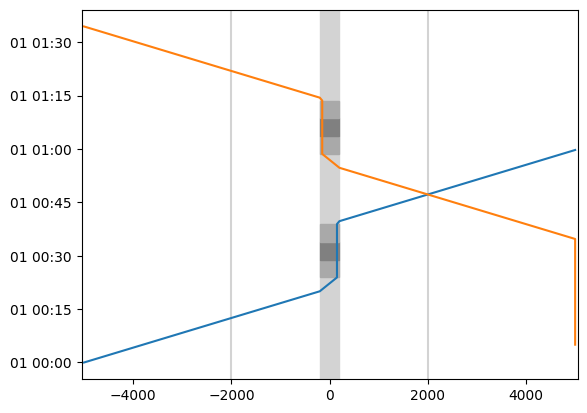

In [ ]:
fig,ax = plt.subplots()

for distances,times in zip(all_distances,all_times):
    ax.plot(distances,times)

ylimmin,ylimmax = ax.get_ylim()

#Plot lock chamber
x_lock_doorsA = lock_edge_geometry.line_locate_point(transform(wgs84rad_to_wgs84eqd,lock.location_lock_doors_A))-lock_edge_geometry.length/2
x_lock_doorsB = lock_edge_geometry.line_locate_point(transform(wgs84rad_to_wgs84eqd,lock.location_lock_doors_B))-lock_edge_geometry.length/2
lock_extend_x = [x_lock_doorsA,x_lock_doorsA,x_lock_doorsB,x_lock_doorsB]
ax.fill(lock_extend_x,[ylimmin,ylimmax,ylimmax,ylimmin],color='lightgrey',zorder=0)

#Plot lock phases
for index, message_info in lock_df.iterrows():
    if message_info.Message == 'Lock doors opening stop' and index != 0:
        time_start = lock_df.loc[index-1,'Timestamp'] 
        time_stop = message_info.Timestamp
        ax.fill(lock_extend_x,[time_start,time_stop,time_stop,time_start],color='darkgrey',zorder=0)
    if message_info.Message == 'Lock doors closing stop' and index != 0:
        time_start = lock_df.loc[index-1,'Timestamp'] 
        time_stop = message_info.Timestamp
        ax.fill(lock_extend_x,[time_start,time_stop,time_stop,time_start],color='darkgrey',zorder=0)
    if message_info.Message == 'Lock chamber converting stop' and index != 0:
        time_start = lock_df.loc[index-1,'Timestamp'] 
        time_stop = message_info.Timestamp
        ax.fill(lock_extend_x,[time_start,time_stop,time_stop,time_start],color='grey',zorder=0)

ax.axvline(-2000,color='lightgrey',zorder=0)
ax.axvline(2000,color='lightgrey',zorder=0)
ax.set_xlim(-5050,5050);
ax.set_ylim(ylimmin,ylimmax);